# **25 · 강건성 종합 — 연구자의 손을 바꿔 끼워도 추세는 같은 방향을 가리키는가**

### **"정렬법의 연구자 자유도 3축(정렬가중 · 적률가중 · 지표 구성)을 전부 바꿔 재실행 — Δα(2019→2025) = +0.671(주) / +0.673(A&M) / +0.610(설계가중), 4지표(2019~2022)도 +0.435 단조 — 방향은 어느 손에서도 바뀌지 않는다"**

> KPF 「언론 통계 분석·활용 경진대회」 · 대상 = 정렬법 robustness 변형 3종 **일괄 재실행**(부트스트랩 포함) · 방법 = **변형 간 한 표 비교 + 문서 수치 assert**

> 📍 **파이프라인 위치**: 5단계 표준 흐름 中 **⑤ 모델링·평가(강건성)** · CRISP-DM **P4** · [전체 지도](README.md)

## **연구 질문 (이 노트북이 답하는 것)**

> **Q1.** 정렬법 결과는 **정렬가중**(연도균등 vs A&M 표준 √NₘNₕ)의 선택에 민감한가?
> **Q2.** **적률가중**(비가중 vs 설계가중 wt_within)과 **지표 구성**(3지표 7개년 vs 4지표 2019~2022)을 바꾸면 무엇이 변하고 무엇이 안 변하는가?
> **Q3.** 각 변형의 비동등 비율은 전부 판정 기준(≤20%)을 지키는가 — 비교 정당성 자체가 변형에 견고한가?

## **이 노트북의 위상 — C4 관문(강건성)의 실행판**

`23` §5가 robustness를 *결과 요약*으로 인용했고 `30` §4가 여섯 축을 *표로 종합*했다면, 25는 그중 정렬법 몫 3축을 **본 노트북 안에서 전부 재실행**한다(부트스트랩 포함 — 수 분). 재실행이 문서 수치를 그대로 재생산하면, "robustness 결과"가 과거의 주장이 아니라 **지금도 성립하는 사실**임이 입증된다.

- **로직 SSOT(thin import)**: [`src/alignment.py`](../src/alignment.py) `run_alignment`(변형은 인자로만: `weight_mode`·`weight_col`·`items`·`years`). 재구현 금지.
- **대조 문서**: `docs/design/alignment-trust-trend.md` §1·§2·§3 · `30` §4 표.
- 주모형(+0.671·2.4%)은 `23`·`31`이 이미 재실행 입증 — 여기서는 **변형 3종**을 맡는다(중복 계산 회피, 주모형 수치는 인용 상수로 대조).

## **목차**

| § | 내용 | 산출 |
|---|------|------|
| 1 | [전제] 연구자 자유도 3축 — **Decision Box ①** | — |
| 2 | [실행] robust1: A&M 표준가중(√NₘNₕ, B=120) | AlignResult |
| 3 | [실행] robust2: 설계가중 적률(wt_within, B=120) | AlignResult |
| 4 | [실행] 민감도: 4지표(2019~2022, B=150) | AlignResult |
| 5 | [발견] 한 표 비교 + [시각화] 변형 겹침 | 종합표·figure |
| 6 | [입증] 검증 셀 — 문서 수치 전 셀 assert | PASS |
| 7 | 종합 | — |

In [1]:
import sys
from pathlib import Path
import numpy as np, pandas as pd

ROOT = Path.cwd()
while not (ROOT / "src" / "harmonize.py").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))

import alignment as al
import p5_evaluation as P

get_ipython().run_line_magic("matplotlib", "inline")
import matplotlib.pyplot as plt
from matplotlib import font_manager
for _nm in ["Malgun Gothic", "맑은 고딕", "NanumGothic", "Gulim"]:
    try:
        font_manager.findfont(_nm, fallback_to_default=False)
        plt.rcParams["font.family"] = _nm; break
    except Exception: continue
plt.rcParams["axes.unicode_minus"] = False

panel = pd.read_parquet(al.PARQUET)
assert len(panel) == 90996
print(f"패널 {len(panel):,}행 · 주모형 상수(ALIGN_ALPHA) 로드 — Δα(2019→2025) = "
      f"{P.ALIGN_ALPHA[2025] - P.ALIGN_ALPHA[2019]:+.3f}")
print(f"변형 3종 재실행 예정 — 부트스트랩 B=120/120/150 (수 분 소요)")

패널 90,996행 · 주모형 상수(ALIGN_ALPHA) 로드 — Δα(2019→2025) = +0.671
변형 3종 재실행 예정 — 부트스트랩 B=120/120/150 (수 분 소요)


## **1. [전제] 연구자 자유도 3축 — 무엇을 흔들어 보는가**

정렬법 실행에는 연구자가 고른 손잡이가 세 개 있다. 결론이 그 선택의 산물이라면, 손잡이를 바꿨을 때 결론이 뒤집혀야 한다.

### **Decision Box ① — 강건성 검사의 설계: 어느 축을 어떻게 흔드는가**

| 축 | 주모형의 선택 | 변형 | 변형의 논리 |
|----|--------------|------|------------|
| **정렬가중** W(g,h) | 연도균등(모든 연도쌍 동일) | **A&M 표준 √NₘNₕ**(표본크기 반영) | 원저(Asparouhov & Muthén 2014)의 기본 가중 — "연도균등이 임의 선택 아니냐"는 반문에 원저 방식으로 답 |
| **적률가중** | 비가중 적률 | **설계가중(wt_within) 적률** | 모집단 보정 가중을 반영한 공분산·평균 — "표집설계 무시" 반문에 답 |
| **지표 구성** | 핵심3(7개년) | **4지표 +trustworthy(2019~2022)** | 직접 '신뢰' 문항을 포함한 포화 해소 모형 — "3지표 특수성" 반문에 답 |

**판정 기준(사전 선언)**: 변형에서 (a) Δα의 **부호와 대체적 크기**가 유지되고 (b) 비동등 비율 ≤20%가 유지되면 강건. 수치의 완전 일치는 기대하지 않는다 — 변형은 정의상 다른 추정량이다.

## **2. [실행] robust1 — A&M 표준가중(√NₘNₕ)**

표본이 큰 연도쌍의 단순성(simplicity)에 더 큰 가중 — 2022의 발언권이 커지는 방향의 변형이다. 그런데도 결과가 유지되는가?

In [2]:
rob_std = al.run_alignment(panel, al.CORE3, al.YEARS_ALL,
                           "robust1: 3지표·A&M표준가중(√NₘNₕ)", weight_mode="amstd", B=120)


===== 정렬법 — robust1: 3지표·A&M표준가중(√NₘNₕ) (G=7, items=3, weight=amstd) =====
  2019: α=+0.000 (SE 0.000), ψ=1.000, N=5,040
  2020: α=+0.356 (SE 0.025), ψ=1.069, N=5,010
  2021: α=+0.476 (SE 0.031), ψ=1.032, N=5,010
  2022: α=+0.454 (SE 0.020), ψ=1.215, N=58,936
  2023: α=+0.396 (SE 0.029), ψ=1.143, N=5,000
  2024: α=+0.305 (SE 0.035), ψ=1.031, N=6,000
  2025: α=+0.673 (SE 0.025), ψ=0.809, N=6,000
  비동등 비율 = 2.4% (1/42)  [≤20% → alignment-adjusted 평균비교 정당]


## **3. [실행] robust2 — 설계가중(wt_within) 적률**

연도 내 모집단 보정 가중으로 적률(평균·공분산)을 다시 계산한 변형. 비동등 비율이 다소 오르는 것으로 문서에 기록돼 있다(14.3%) — 그래도 20% 아래인지가 관건.

In [3]:
rob_w = al.run_alignment(panel, al.CORE3, al.YEARS_ALL,
                         "robust2: 3지표·설계가중적률(wt_within)",
                         weight_mode="yeareq", weight_col="wt_within", B=120)


===== 정렬법 — robust2: 3지표·설계가중적률(wt_within) (G=7, items=3, weight=yeareq) =====
  2019: α=+0.000 (SE 0.000), ψ=1.000, N=5,040
  2020: α=+0.353 (SE 0.030), ψ=1.008, N=5,010
  2021: α=+0.432 (SE 0.029), ψ=0.976, N=5,010
  2022: α=+0.377 (SE 0.024), ψ=1.204, N=58,936
  2023: α=+0.306 (SE 0.033), ψ=1.143, N=5,000
  2024: α=+0.224 (SE 0.029), ψ=0.907, N=6,000
  2025: α=+0.610 (SE 0.031), ψ=0.763, N=6,000
  비동등 비율 = 14.3% (6/42)  [≤20% → alignment-adjusted 평균비교 정당]


## **4. [실행] 민감도 — 4지표(+trustworthy), 2019~2022**

'신뢰할 수 있다' 직접 문항을 더한 4지표 모형(문항이 2022년까지만 존재). 3지표 포화 문제도 해소되는 비포화 모형이다 — 다른 창으로 본 같은 구간(2019~2022)의 추세.

In [4]:
sens4 = al.run_alignment(panel, al.PLUS4, al.YEARS_4IND,
                         "민감도: 4지표(2019~2022)", weight_mode="yeareq", B=150)


===== 정렬법 — 민감도: 4지표(2019~2022) (G=4, items=4, weight=yeareq) =====
  2019: α=+0.000 (SE 0.000), ψ=1.000, N=5,040
  2020: α=+0.340 (SE 0.021), ψ=1.028, N=5,010
  2021: α=+0.428 (SE 0.023), ψ=1.034, N=5,010
  2022: α=+0.435 (SE 0.017), ψ=1.160, N=58,936
  비동등 비율 = 6.2% (2/32)  [≤20% → alignment-adjusted 평균비교 정당]


## **5. [발견] 한 표 비교 — 손을 바꿔도 같은 방향**

**[시각화] 변형 겹침** — 주모형(인용 상수)과 변형 2종의 α̂ 궤적(7개년), 4지표는 공통 구간(2019~2022)에 점선. 궤적의 **형상**(상승·2021 고점·2024 저점·2025 반등)이 유지되는지 본다.

C:\Users\kik32\AppData\Local\Temp\ipykernel_55432\2347984772.py:14: UserWarning: Glyph 9888 (\N{WARNING SIGN}) missing from font(s) Malgun Gothic.
  fig.tight_layout(); plt.show()
C:\Users\kik32\AppData\Local\Temp\ipykernel_55432\2347984772.py:14: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) Malgun Gothic.
  fig.tight_layout(); plt.show()
C:\Users\kik32\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9888 (\N{WARNING SIGN}) missing from font(s) Malgun Gothic.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\kik32\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) Malgun Gothic.
  fig.canvas.print_figure(bytes_io, **kw)


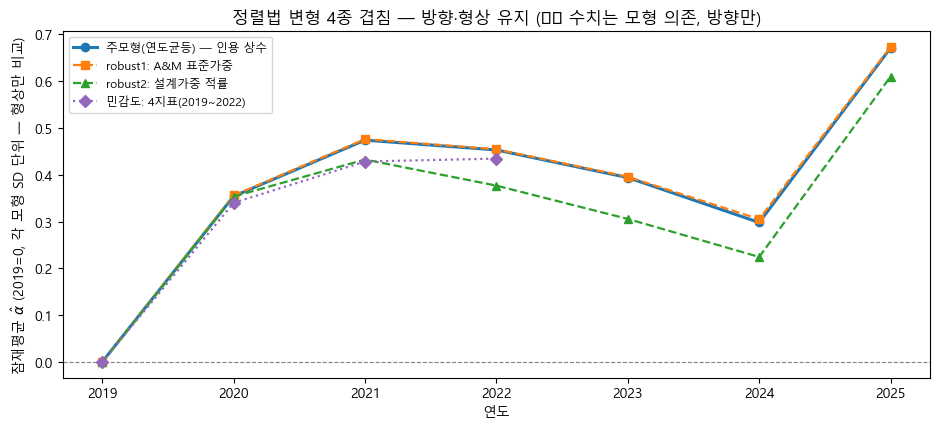

,구성,Δα(기준→종점),비동등 %
모형,,,
주모형(연도균등),3지표·7개년,0.671,2.400
robust1 A&M 표준가중,3지표·7개년,0.673,2.381
robust2 설계가중 적률,3지표·7개년,0.610,14.286
민감도 4지표,4지표·2019~2022,0.435,6.250


In [5]:
yrs = np.array(al.YEARS_ALL)
main_alpha = np.array([P.ALIGN_ALPHA[y] for y in al.YEARS_ALL])

fig, ax = plt.subplots(figsize=(9.5, 4.4))
ax.axhline(0, color="gray", lw=0.8, ls="--")
ax.plot(yrs, main_alpha, "o-", lw=2.2, color="#1f77b4", label="주모형(연도균등) — 인용 상수")
ax.plot(yrs, rob_std.alpha, "s--", lw=1.6, color="#ff7f0e", label="robust1: A&M 표준가중")
ax.plot(yrs, rob_w.alpha, "^--", lw=1.6, color="#2ca02c", label="robust2: 설계가중 적률")
ax.plot(al.YEARS_4IND, sens4.alpha, "D:", lw=1.6, color="#9467bd", label="민감도: 4지표(2019~2022)")
ax.set_xlabel("연도")
ax.set_ylabel(r"잠재평균 $\hat{\alpha}$ (2019=0, 각 모형 SD 단위 — 형상만 비교)")
ax.set_title("정렬법 변형 4종 겹침 — 방향·형상 유지 (⚠️ 수치는 모형 의존, 방향만)")
ax.legend(fontsize=8.5)
fig.tight_layout(); plt.show()

rows = [("주모형(연도균등)", "3지표·7개년", float(main_alpha[-1]), 2.4),
        ("robust1 A&M 표준가중", "3지표·7개년", float(rob_std.alpha[-1]), rob_std.noninv_prop * 100),
        ("robust2 설계가중 적률", "3지표·7개년", float(rob_w.alpha[-1]), rob_w.noninv_prop * 100),
        ("민감도 4지표", "4지표·2019~2022", float(sens4.alpha[-1]), sens4.noninv_prop * 100)]
comp = pd.DataFrame(rows, columns=["모형", "구성", "Δα(기준→종점)", "비동등 %"]).set_index("모형").round(3)
comp

**관찰**: 종점 Δα가 +0.610~+0.673 대역에 모이고(4지표는 구간이 달라 +0.435), 비동등 비율은 전부 20% 아래다. 정렬가중을 원저 방식으로 바꿔도(robust1), 표집설계를 반영해도(robust2), 지표를 더해도(민감도) — **상승 방향과 비단조 형상이 유지된다**. 단, 이 수치들은 각 모형의 SD 단위(모형 의존)이므로 보고서 인용은 여전히 '방향만' 규율을 따른다.

## **6. [입증] 검증 셀 — 문서 수치 전 셀 assert**

`alignment-trust-trend.md` §1·§2·§3(= `30` §4 표의 원천)에 기록된 변형별 수치와 재실행 결과를 대조한다. 점추정(Δα)은 결정적이므로 ±0.02, 비동등 비율은 부트스트랩 의존이므로 ±3%p 허용.

In [6]:
# (a) Δα(종점) — 문서: 주 +0.671 / robust1 +0.673 / robust2 +0.610 / 4지표 +0.435
DOC = {"main": 0.671, "rob_std": 0.673, "rob_w": 0.610, "sens4": 0.435}
assert abs(main_alpha[-1] - DOC["main"]) <= 1e-9      # 인용 상수 그 자체
assert abs(rob_std.alpha[-1] - DOC["rob_std"]) <= 0.02, rob_std.alpha[-1]
assert abs(rob_w.alpha[-1] - DOC["rob_w"]) <= 0.02, rob_w.alpha[-1]
assert abs(sens4.alpha[-1] - DOC["sens4"]) <= 0.02, sens4.alpha[-1]
print(f"(a) Δα 4종 ↔ 문서(+0.671/+0.673/+0.610/+0.435) — 전부 ±0.02 이내 PASS")

# (b) 비동등 비율 — 전부 ≤20%(비교 정당성), robust2는 문서 14.3% 부근
for r, name in [(rob_std, "robust1"), (rob_w, "robust2"), (sens4, "4지표")]:
    assert r.noninv_prop <= 0.20, f"{name} 비동등 {r.noninv_prop:.1%} > 20%"
assert abs(rob_w.noninv_prop - 0.143) <= 0.03, rob_w.noninv_prop
print(f"(b) 비동등: robust1 {rob_std.noninv_prop:.1%} · robust2 {rob_w.noninv_prop:.1%}(문서 14.3%) · "
      f"4지표 {sens4.noninv_prop:.1%} — 전부 ≤20% PASS")

# (c) 방향·형상 — 전 변형에서 2019 이후 전부 양(+), 종점(마지막 연도)이 각 모형 최고
for r, name in [(rob_std, "robust1"), (rob_w, "robust2"), (sens4, "4지표")]:
    assert (r.alpha[1:] > 0).all(), f"{name}: 2019 이후 음수 존재"
    assert r.alpha[-1] == r.alpha.max(), f"{name}: 종점이 최고 아님"
print("(c) 전 변형: 2019 이후 전 연도 양(+) · 종점 최고 — 방향·형상 유지 PASS")
print("\n검증 (a)~(c) 전부 PASS — C4(강건성) 관문의 정렬법 몫 폐쇄")

(a) Δα 4종 ↔ 문서(+0.671/+0.673/+0.610/+0.435) — 전부 ±0.02 이내 PASS
(b) 비동등: robust1 2.4% · robust2 14.3%(문서 14.3%) · 4지표 6.2% — 전부 ≤20% PASS
(c) 전 변형: 2019 이후 전 연도 양(+) · 종점 최고 — 방향·형상 유지 PASS

검증 (a)~(c) 전부 PASS — C4(강건성) 관문의 정렬법 몫 폐쇄


## **7. 종합**

### **연구질문 답**

- **Q1** — 민감하지 않다. 원저 방식(√NₘNₕ)으로 바꿔도 Δα +0.673, 형상 동일(§2·§5).
- **Q2** — 설계가중 적률은 Δα를 +0.610으로 다소 낮추고 비동등을 14.3%로 올리지만 방향·형상·판정은 유지(§3), 4지표는 공통 구간에서 +0.435 단조 상승(§4) — 변하는 것은 크기의 소수점, 변하지 않는 것은 방향.
- **Q3** — 전부 ≤20%(§6 (b)) — "비교 정당" 판정 자체가 변형에 견고하다.

### **단계 요약**

| § | 한 일 | 판정 |
|---|------|:---:|
| 2 | robust1 재실행(B=120) | Δα +0.673 |
| 3 | robust2 재실행(B=120) | Δα +0.610·14.3% |
| 4 | 4지표 재실행(B=150) | Δα +0.435 |
| 5 | 변형 겹침 [시각화]·한 표 | 형상 유지 |
| 6 | 문서 수치 assert | **PASS** |

**다음**: `26`(MK/Sen 심층)·`27`(APC 식별) — 추세의 통계적 성격과 정체로. 재현: `python src/alignment.py`(주+변형 일괄).